In [1]:
# Problem Set #1
# Brandon Bath
# MGT 665
# 3/26/26
# This problem set uses the principles learned in Lab 1 to look at the relationship between horsepower (hp) and miles per gallon (mpg)
# using simple linear regression, and in part 2 adds in weight and acceleration as predictors using multiple linear regression.

In [2]:
# importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [4]:
# Section 1 (Load and Explore the Dataset) Explanation: In this section the code loads the data from the url and uses "drop" to remove any missing data for the model. 
# The results show us stats we can use to analyze before building our models. 

In [5]:
url = "https://www.statlearning.com/s/Auto.csv"
auto = pd.read_csv(url, na_values='?').dropna()

print("=" * 60)
print("SECTION 1: Dataset Overview")
print("=" * 60)
print(f"\nDataset shape: {auto.shape}")
print(f"\nColumn names: {list(auto.columns)}")
print(f"\nFirst 5 rows:")
print(auto.head())
print(f"\nSummary statistics:")
print(auto.describe())

SECTION 1: Dataset Overview

Dataset shape: (392, 9)

Column names: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']

First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    70   
4  17.0          8         302.0       140.0    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Summary statistics:
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000 

In [6]:
# Section 1 Results Explanation: After dropping "na" our dataset has 392 data points. 
# The mean mpg is about 23.45 which is a baseline number to compare our results to. 

In [7]:
# Section 2 (Simple Linear Regression) Explanation: In this section the code builds a simple linear regression model using horsepower
# as the predictor variable, and miles per gallon as the outcome.
# Our goal is to see how a change in hp affects mpg. We expect to see a decrease in mpg as hp increases. 

In [8]:
print("\n" + "=" * 60)
print("SECTION 2: Simple Linear Regression")
print("Predictor: horsepower | Outcome: mpg")
print("=" * 60)

X = sm.add_constant(auto['horsepower'])
y = auto['mpg']

model = sm.OLS(y, X).fit()
print(model.summary())


SECTION 2: Simple Linear Regression
Predictor: horsepower | Outcome: mpg
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        17:10:52   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [9]:
# Section 3 (Prediction) Explanation: We use our model to predict the mpg for a vehicle with 98 hp.

In [10]:
print("\n" + "=" * 60)
print("SECTION 3: Prediction")
print("=" * 60)

predicted_mpg = model.predict([1, 98])
print(f"\nPredicted mpg for horsepower = 98: {predicted_mpg[0]:.4f}")


SECTION 3: Prediction

Predicted mpg for horsepower = 98: 24.4671


In [11]:
# Section 4 (Scatterplot with Regression Line) Explanation: We create a scatterplot to visualize the data and regression line.


SECTION 4: Scatterplot with Regression Line


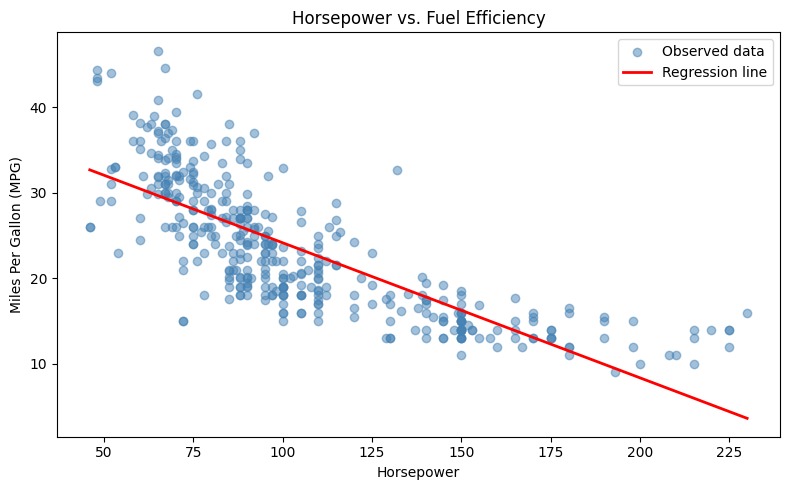

Scatterplot saved as scatterplot.png


In [12]:
print("\n" + "=" * 60)
print("SECTION 4: Scatterplot with Regression Line")
print("=" * 60)

plt.figure(figsize=(8, 5))
plt.scatter(auto['horsepower'], auto['mpg'],
            alpha=0.5, color='steelblue', label='Observed data')

hp_range = np.linspace(auto['horsepower'].min(),
                        auto['horsepower'].max(), 100)
mpg_pred = model.predict(sm.add_constant(hp_range))
plt.plot(hp_range, mpg_pred, color='red',
         linewidth=2, label='Regression line')

plt.xlabel('Horsepower')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Horsepower vs. Fuel Efficiency')
plt.legend()
plt.tight_layout()
plt.savefig('scatterplot.png')
plt.show()
print("Scatterplot saved as scatterplot.png")

In [13]:
# Part 1: Simple Linear Regression
# 1. Intercept: 39.94
#    Coefficient: -0.1578
#    R-squared: 0.606 (this means this model accounts for about 60% of the change in mpg)
# 2. There is a stastically significant relationship between hp and mpg. We know this because hp has a very small p-value
#    and is under 0.05 which is the standard significance level. Because of this, we reject the null hypothesis. 
# 3. The predicted mpg for a car with 98 hp is about 24.47 mpg
#    We plug 98 into our model: mpg = 39.9359 - 0.1578(98) which equals 24.4671
# 4. There is a clear negative trend with mpg as hp increases. The relationship appears to be linear, but it appears to change
#    its slope between 150-175 and flatten out. 

In [14]:
# Section 5 (Multiple Linear Regression) Explanation: In this section the code adds in weight and acceleration as predictor variables.
# This is helpful because our simple linear regression model only accounted for 60% of changes in mpg. 

In [15]:
print("\n" + "=" * 60)
print("SECTION 5: Multiple Linear Regression")
print("Predictors: horsepower, weight, acceleration | Outcome: mpg")
print("=" * 60)

X_multi = sm.add_constant(auto[['horsepower', 'weight', 'acceleration']])
model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

print("\n" + "=" * 60)
print("Program complete.")
print("=" * 60)


SECTION 5: Multiple Linear Regression
Predictors: horsepower, weight, acceleration | Outcome: mpg
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     311.1
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          7.48e-103
Time:                        17:10:59   Log-Likelihood:                -1121.0
No. Observations:                 392   AIC:                             2250.
Df Residuals:                     388   BIC:                             2266.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [16]:
# Part 2: Multiple Linear Regression
# 1. Intercept: 45.68
#    Horsepower Coefficient: -0.0475
#    Weight Coefficient: -0.0058
#    Acceleration: -0.0021
#    R-squared: 0.706 (this means this model accounts for about 70% of the change in mpg and is a 10% increase from simple)
# 2. There is a stastically significant relationship between hp and mpg and weight and mpg. We know this because hp and weight
#    both have p-values under 0.05 which is the standard significance level. Acceleration is not statistically significant for this 
#    model.
# 3. The R-squared value increased by about 10% compared to the simple linear regression model indicating that multiple regression is 
#    a better model than simple. This suggests that multiple variables impact mpg, not just hp. 
# 4. The weight coefficient of -0.0058 means that for every one pound increase in weight of a vehicle, mpg decreases by 0.0058. Heavier cars
#    get worse mpg on average. 

In [17]:
# Part 3: Conceptual Questions
# 1. Simple linear regression uses only one predictor variable, while multiple linear regression uses more than one. Simple is appropriate
#    when there is only one relationship that affects the outcome in a signficant way, and as a starting point when doing analysis. 
#    Multiple is appropriate when multiple factors affect an outcome in a signifcant way, and takes those variables into account to provide
#    a more accurate model. 
# 2. R-squared shows how much of the change in the outcome variable is explained by our model. The Adjusted R-squared value is useful in
#    situations with multiple predictor variables because it penalizes a model that adds variables that don't actually improve it. 
# 3. The single most important factor that determines a car's fuel efficiency appears to be weight. The simple linear regression model had hp
#    with a p-value very low (showing 0.000). The p-value for hp increased to 0.003 when weight was added using multiple linear regression, 
#    while weight's p-value is the lowest (showing at 0.000). Both are statistically significant, but weight is more significant for this model. 